In [1]:
import jax.numpy as jnp
import jax
from jax import random
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from lqg.tracking import PointMassBoundedActor, BoundedActor
from lqg import xcorr

## Point mass hand dynamics model

The hand dynamics are given by a point-mass model commonly used to describe reaching movements (see e.g. Kausuga et al., 2022, for details). Concretely, the continuous-time dynamics for the hand's velocity $v$ and muscle force $f$ are
\begin{align}
    m \dot v &= f, \\
    \tau \dot f &= - f + u + \epsilon_t,
\end{align}
where $m$ is the mass of the hand, $\tau$ is the muscle time constant, and $u$ is the motor command and $\epsilon_t$ is motor noise. We set the mass to $m = 1 kg$, which we can do without loss of generality since a rescaling of the mass is equivalent to a rescaling of the motor cost matrix in this model. We set the muscle time constant to a commonly used value in the literature of $\tau = 66 ms$ (e.g. Kasuga et al., 2022).

We discretize this continuous-time system with time step $dt$ to obtain the discrete-time matrices $\mathbf A_\text{hand}$ and $\mathbf B_\text{hand}$, and the discrete time noise covariance $\mathbf \Sigma_\text{hand}$.

The state is defined as $\mathbf x_t = \left[p_\text{target}(t), p_\text{hand}(t), v_\text{hand}(t), f_\text{hand}(t)\right]^\top$. Stacking up the dynamics of the target and hand, we obtain our full system.

The observation function of the model assumes that the agent only observes the position of the target and hand (each with their own noise parameters).

Note that the motor noise parameter no longer has the same interpretation as in the standard model, as it operates on a control signal which is a change in force (rather than directly a hand velocity).

The cost function is

\begin{equation}
    \sum_{t=0}^{T} \left[ (p_\text{target}(t) - p_\text{hand}(t))^2 + c_v v_\text{hand}(t)^2 + c_f f_\text{hand}(t)^2 + c_u u_t^2 \right].
\end{equation}

This cost function has the following parameters:
- action cost $c$
- velocity cost $c_v$
- force cost $c_f$



## Simulation

We now simulate both our previous model and the new point mass dynamics model for the same target trajectory and compare their behaviour. You can see that the model with the point mass dynamics produces smoother trajectories.

Simulating model: <lqg.tracking.point_mass.PointMassBoundedActor object at 0x11cb3e0f0>
Simulating model: <lqg.tracking.basic.BoundedActor object at 0x12e058050>


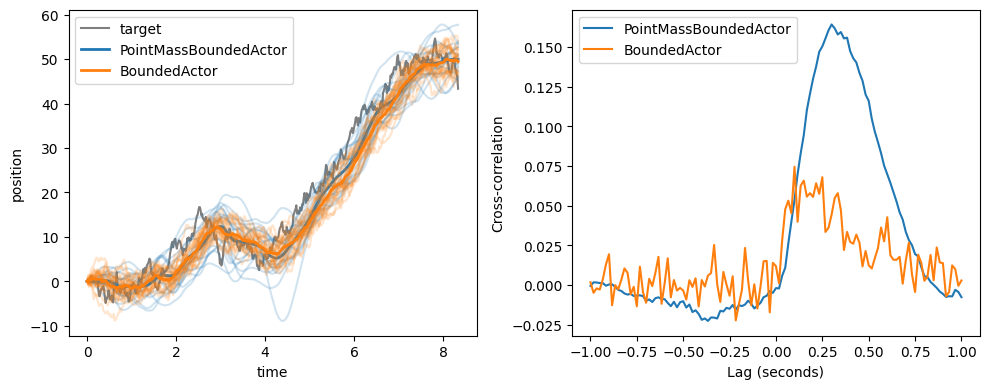

In [4]:
T = 500
dt = 1 / 60.0


model = PointMassBoundedActor(T=T, dt=dt)
# simulate the model. This is just to obtain a single target trajectory for which we can then simulate both models and compare their behavior.
x_target = model.simulate(random.PRNGKey(0), x0=jnp.zeros(model.xdim), n=1)
x_target = jnp.tile(x_target, (20, 1, 1))

f, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(jnp.arange(T + 1) * dt, x_target[0, :, 0], color="k", alpha=0.5, label="target")
for i, model in enumerate([
    PointMassBoundedActor(T=T, action_variability=0.5, dt=dt, velocity_cost=0.001, force_cost=0.001, action_cost=1e-5),
    BoundedActor(T=T, action_cost=0.1, action_variability=0.5, dt=dt)
]):
    print(f"Simulating model: {model}")

    # simulate the model with the same target trajectory and plot the resulting trajectories
    dim_mask = (
        jnp.array([0, 1], dtype=bool)
        if isinstance(model, BoundedActor)
        else jnp.array([0, 1, 1, 1], dtype=bool)
    )
    x_sim = model.simulate_actions(
        x_target[..., : model.xdim], action_dim_mask=dim_mask, rng_key=random.PRNGKey(0)
    )

    # visualize trajectories (mean and individual trajectories)
    ax[0].plot(jnp.arange(T + 1) * dt, x_sim[:, :, 1].T, color=f"C{i}", alpha=0.2)
    ax[0].plot(jnp.arange(T + 1) * dt, x_sim[:, :, 1].mean(axis=0), color=f"C{i}", linewidth=2, label=model.__class__.__name__)

    x = model.simulate(n=20, rng_key=random.PRNGKey(0), x0=jnp.zeros(model.xdim))
    vel = jnp.diff(x, axis=-2)

    lags, correls = xcorr(vel[..., 1], vel[..., 0])
    ax[1].plot(lags * dt, correls.mean(axis=0), color=f"C{i}", label=model.__class__.__name__)

ax[0].set_xlabel("time")
ax[0].set_ylabel("position")
ax[0].legend()
ax[1].set_xlabel("Lag (seconds)")
ax[1].set_ylabel("Cross-correlation")
ax[1].legend()
f.tight_layout()
plt.show()


## Model fitting with maximum likelihood

I added some utility function to estimate model parameters with maximum likelihood instead of Bayesian inference. This should be much faster, but will only give you a point estimate of the parameters instead of a full posterior distribution.

In [5]:
true_params = {
    "sigma_target": 20.0,
    "sigma_cursor": 12.5,
    "action_cost": 1e-5,
    "action_variability": 0.5,
    "velocity_cost": 0.01,
    "force_cost": 0.01,
}

# set up the model with known parameters to simulate some synthetic data 
model = PointMassBoundedActor(T=500, **true_params)

# We assume that we have access to the target and hand positions, but not the hand velocity and muscle activation, as in a real experiment. 
# Therefore, we only use the first two dimensions of the state vector for inference on our simulated data.
x_data = model.simulate(random.PRNGKey(0), x0=jnp.zeros(model.xdim), n=20)[..., :2]

In [11]:
from lqg.infer.mle import max_likelihood, Box, LogBox

# We assume that we know the time constant of the muscle activation dynamics, and therefore we fix it to its true value.
# We will infer the other parameters from the simulated data. This is just to illustrate how to set some parameters to fixed values during inference.
fixed_params = {
    "tau": 0.066,
}

# We can define constraints for the optimization. 
# Here, we assume that the parameters are positive and within a reasonable range. 
# The Box and LogBox classes define the lower and upper bounds for each parameter.
# For the LogBox, the optimization will be performed in log-space, which is useful for parameters that can vary over several orders of magnitude.
params_constraints = {
    "sigma_target": Box(1e-3, 1e3),
    "sigma_cursor": Box(1e-3, 1e3),
    "action_cost": LogBox(1e-5, 1e-1),
    "action_variability": Box(1e-3, 1e1),
    "velocity_cost": LogBox(1e-5, 1e-1),
    "force_cost": LogBox(1e-5, 1e-1),
}

params = max_likelihood(
    key=random.PRNGKey(0),
    x=x_data,
    model=PointMassBoundedActor,
    constraints=params_constraints,
    max_steps=1_000,
    num_restarts=20,
    **fixed_params,
)

In [12]:
params

{'action_cost': Array(5.56497735e-05, dtype=float64),
 'action_variability': Array(0.49998014, dtype=float64),
 'force_cost': Array(0.01020973, dtype=float64),
 'sigma_cursor': Array(13.05472311, dtype=float64),
 'sigma_target': Array(15.02444679, dtype=float64),
 'velocity_cost': Array(0.01966398, dtype=float64)}

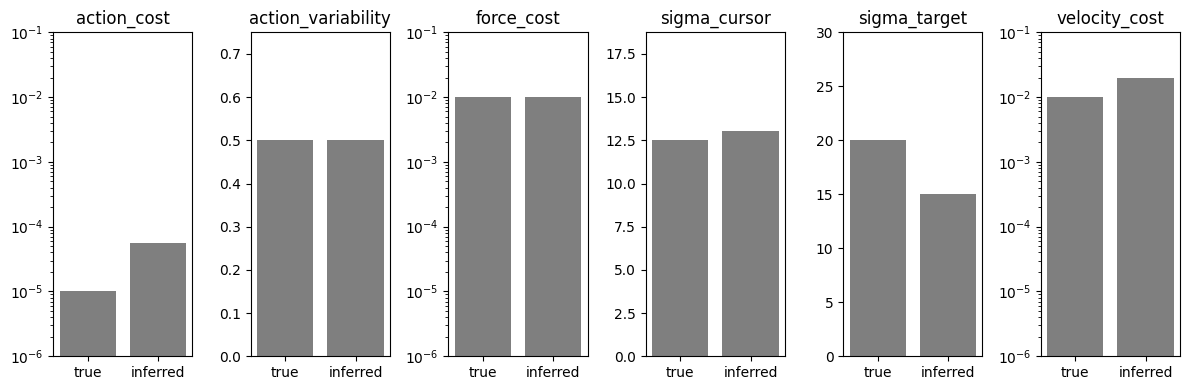

In [13]:
f, ax = plt.subplots(1, len(params), figsize=(12, 4))

for i, name in enumerate(params):
    ax[i].bar("true", true_params[name], color="k", alpha=0.5)
    ax[i].bar("inferred", params[name], color="k", alpha=0.5)
    ax[i].set_title(name)
    
    if name in ["action_cost", "velocity_cost", "force_cost"]:
        ax[i].set_yscale("log")

        ax[i].set_ylim([1e-6, 1e-1])
    else:
        ax[i].set_ylim([0, 1.5 * true_params[name]])

f.tight_layout()
plt.show()

## Parameter recovery analysis

To check that the maximum likelihood estimation procedure recovers the true parameters reliably from simulated data, we can run a parameter recovery analysis. We sample parameters from some prior distributions 100 times, simulate data for each set of parameters, and infer the maximum likelihood parameters. Then we plot the true values against the estimated values.

In [13]:
from tqdm import tqdm

from lqg.infer.models import get_model_params
from lqg.infer.utils import sample_from_prior
from lqg.infer.mle import sample_within_bounds

fixed_params = {
    "process_noise": 1.0,
    "dt": 1.0 / 60.0,
    "tau": 0.066,
}

true_values = {
    key: []
    for key in get_model_params(PointMassBoundedActor)
    if key not in fixed_params
}
results = {
    key: []
    for key in get_model_params(PointMassBoundedActor)
    if key not in fixed_params
}
print("Running maximum likelihood parameter recovery")
for seed in tqdm(range(50)):
    # true_params sampled from prior
    true_params = {
        name: sample_within_bounds(key, name)
        for name, key in zip(get_model_params(PointMassBoundedActor), random.split(random.PRNGKey(seed), num=len(get_model_params(PointMassBoundedActor))))
        if name not in fixed_params
    }

    lqg = PointMassBoundedActor(
        **fixed_params,
        **true_params,
        T=500,
    )

    x = lqg.simulate(rng_key=random.PRNGKey(seed), n=20)

    params = max_likelihood(
        key=random.PRNGKey(seed),
        x=x[..., :2],
        model=PointMassBoundedActor,
        max_steps=1_000,
        num_restarts=10,
        **fixed_params,
    )

    for key, item in params.items():
        true_values[key].append(float(true_params[key]))
        results[key].append(float(item))



Running maximum likelihood parameter recovery


100%|██████████| 50/50 [04:49<00:00,  5.79s/it]


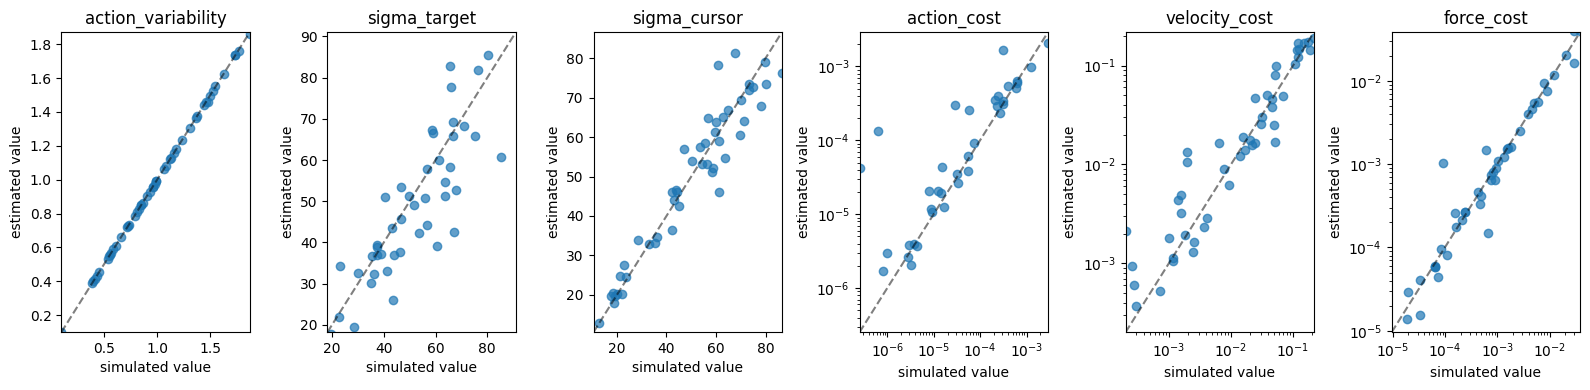

In [14]:
figure, axes = plt.subplots(1, len(true_values), figsize=(16, 4))
for axis, (name, true, estimates) in zip(
    axes.flat, zip(true_values.keys(), true_values.values(), results.values())
):
    axis.scatter(true, estimates, alpha=0.7)
    axis.plot([min(true), max(true)], [min(true), max(true)], "k--", alpha=0.5)
    axis.set_title(name)
    axis.set_xlabel("simulated value")
    axis.set_ylabel("estimated value")
    axis.set_xlim(min(true), max(true))
    axis.set_ylim(min(true), max(true))

    if name in ["action_cost", "velocity_cost", "force_cost"]:
        axis.set_xscale("log")
        axis.set_yscale("log")

figure.tight_layout()
plt.show()